## ***Diabeties Prediction App***

### **Step 1: Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Step 2: Loading Diabeties Dataset**

In [3]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## **Step 3: Performing Basic Exploratory Data Analysis**

### **Checking Null Items** 

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### __Basic Structure of the Dataset__

In [5]:
print(df.shape)
print(df.info())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


### **Checking Duplicate Values in Dataset**

In [6]:
print(df.duplicated().sum())

df = df.drop_duplicates()

0


### **Identifying Unique Values from Dataset**

In [24]:
for col in df.columns:
    print(col, df[col].nunique())

Pregnancies 17
Glucose 136
BloodPressure 47
SkinThickness 51
Insulin 186
BMI 248
DiabetesPedigreeFunction 517
Age 52
Outcome 2


### **Statistical Summary**

In [8]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

### **Visualization**

### *1. Target Distribution (Bar Chart)*

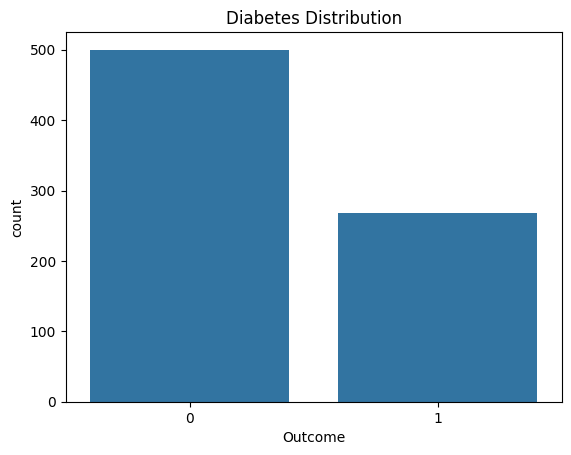

In [9]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

### *2. Feature Distribution (Histogram)*

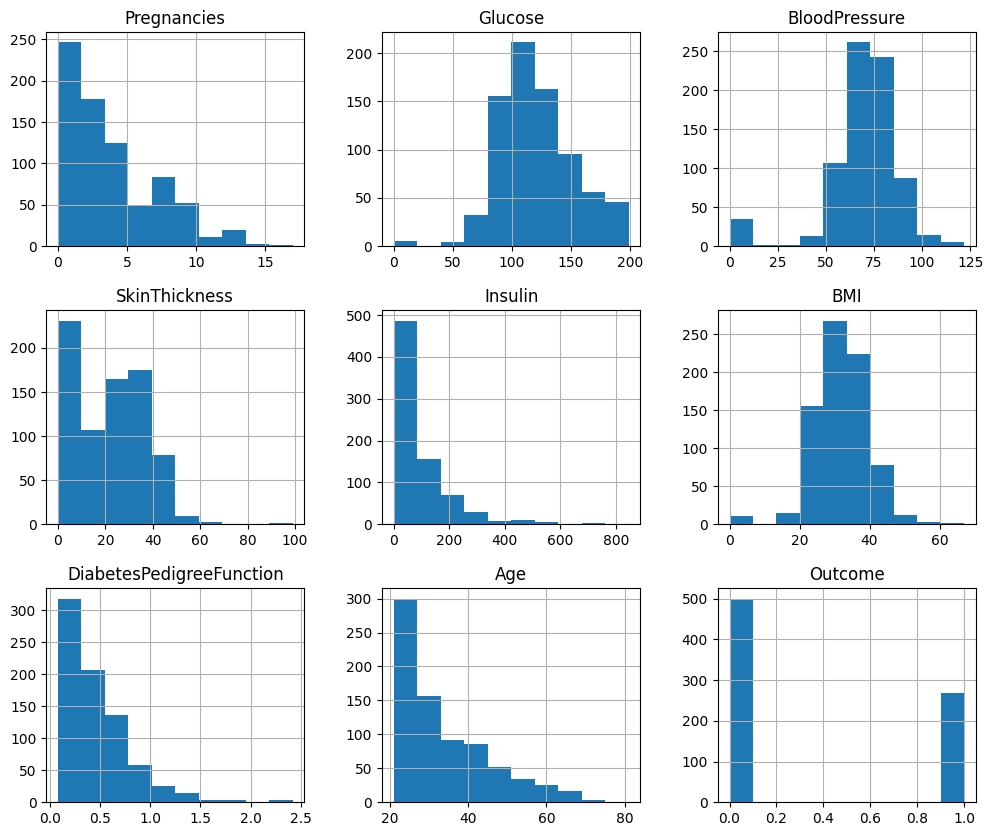

In [10]:
df.hist(figsize=(12,10))
plt.show()

### *3. Correlation Heatmap*

<Axes: >

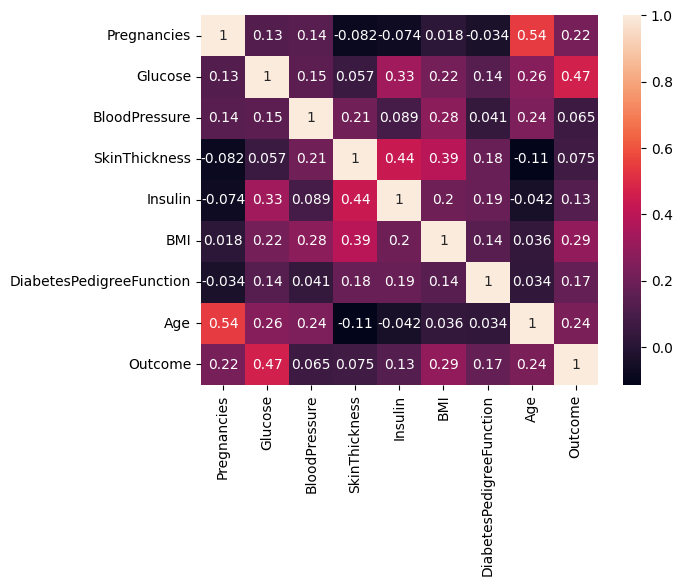

In [11]:
sns.heatmap(df.corr(), annot=True)

### *4. Feature vs Target (Box Plot)*

<Axes: xlabel='Outcome', ylabel='Glucose'>

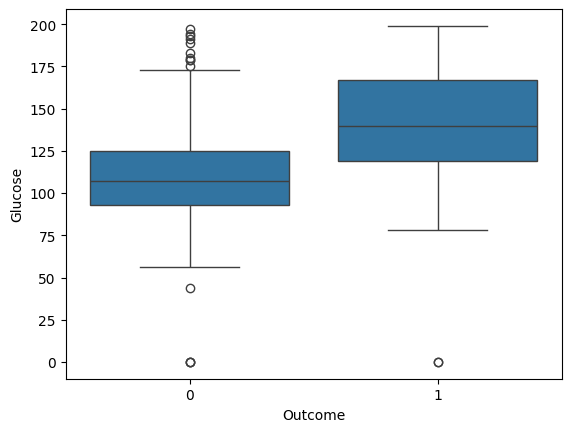

In [12]:
sns.boxplot(x="Outcome", y="Glucose", data=df)

### *5. Insight using Line chart*

<Axes: xlabel='Age'>

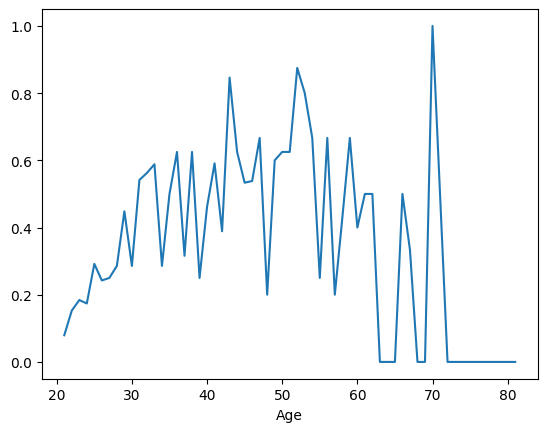

In [13]:
df.groupby("Age")["Outcome"].mean().plot()

## **Step 4: Train Test Split**

In [18]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Save files
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model & Scaler saved!")

Model & Scaler saved!


## **Step 5: Choosing Prediction model**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

model_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    model_scores[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7532
Random Forest: 0.7273
Gradient Boosting: 0.7468
SVM: 0.7338


## **Step 6: Display Best Accurate Model**

In [25]:
best_model_name = max(model_scores, key=model_scores.get)
best_model_score = model_scores[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_model_score:.4f}")

Best Model: Logistic Regression
Accuracy: 0.7532
